# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset yang digunakan adalah data sekunder berupa harga penutupan harian (Closing Price) Bitcoin (BTC) terhadap USD dalam kurun waktu 2021-2025, yang diunduh melalui Yahoo Finance.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [14]:
# Terminal Commands

# Library Standar & Manipulasi Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [15]:
df = pd.read_csv('../btc_raw.csv')
display(df.head())

,Date,Close,High,Low,Open,Volume
0,2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
1,2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2,2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
3,2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
4,2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Ringkasan Statistik ---


,Close,High,Low,Open,Volume
count,2191.000000,2191.000000,2191.000000,2191.000000,2.191000e+03
mean,47176.454669,48067.952570,46165.483711,47141.224589,3.648349e+10
std,31415.243784,31894.220447,30897.419137,31414.701694,2.163183e+10
min,4970.788086,5331.833984,4106.980957,5002.578125,5.331173e+09
25%,22185.371094,22598.989258,21453.022461,22013.654297,2.221047e+10
50%,39747.503906,40713.890625,38706.093750,39738.722656,3.196225e+10
75%,64475.617188,65807.613281,63105.447266,64398.798828,4.539186e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11



--- Cek Missing Values ---
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


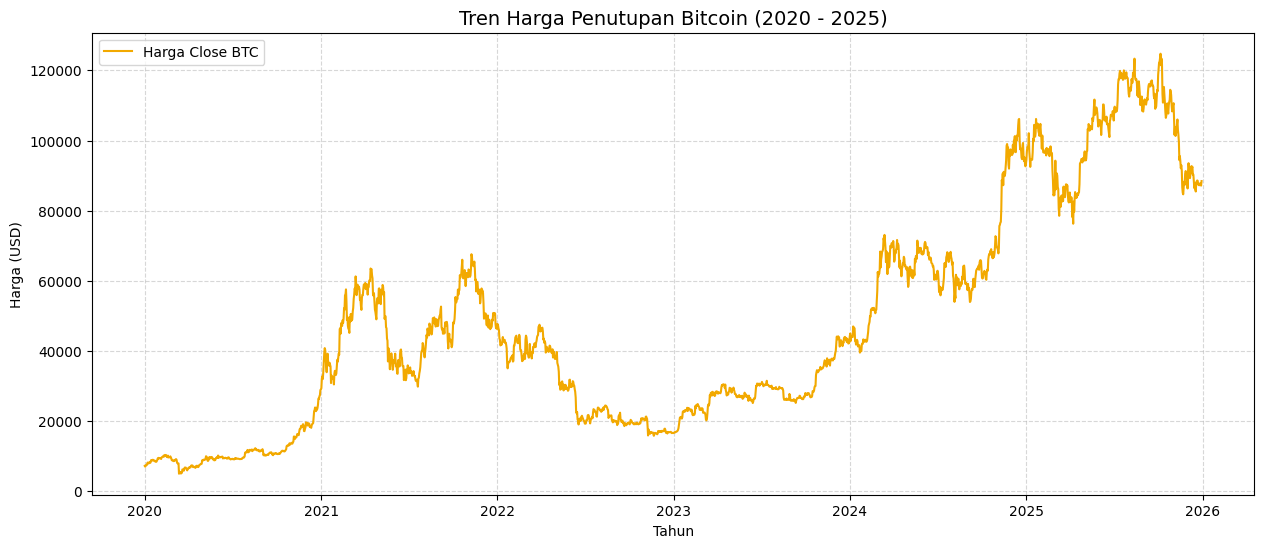

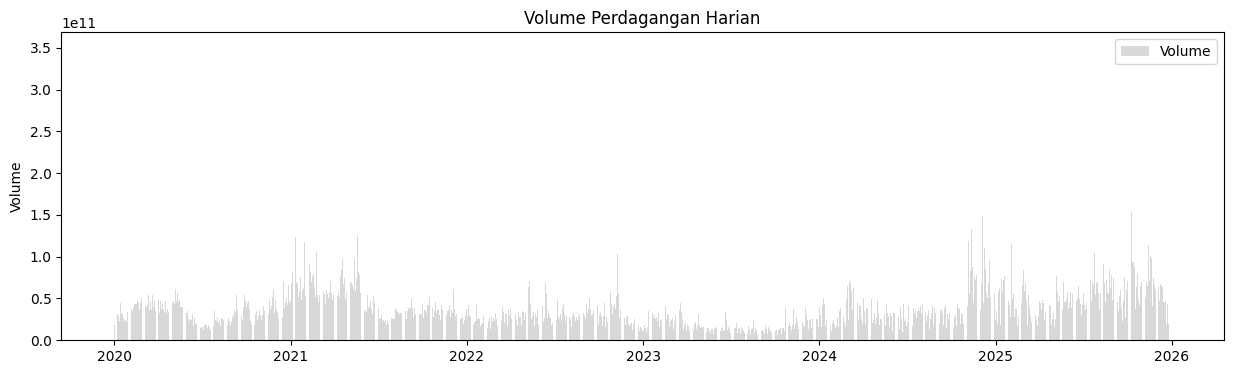

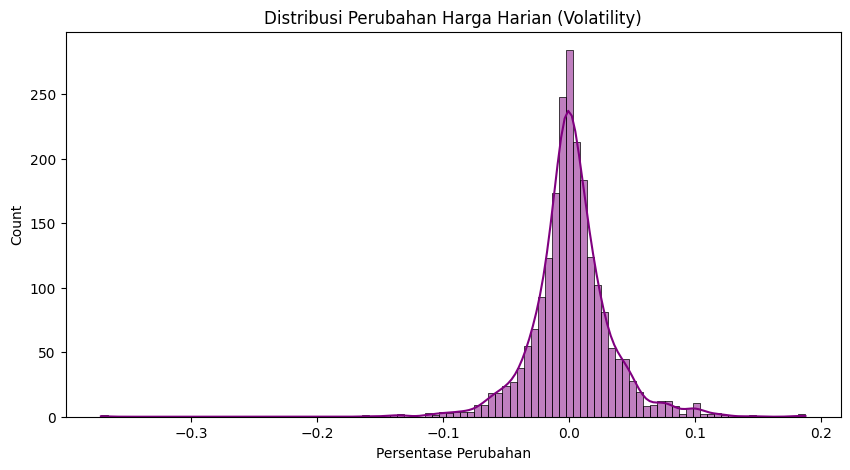

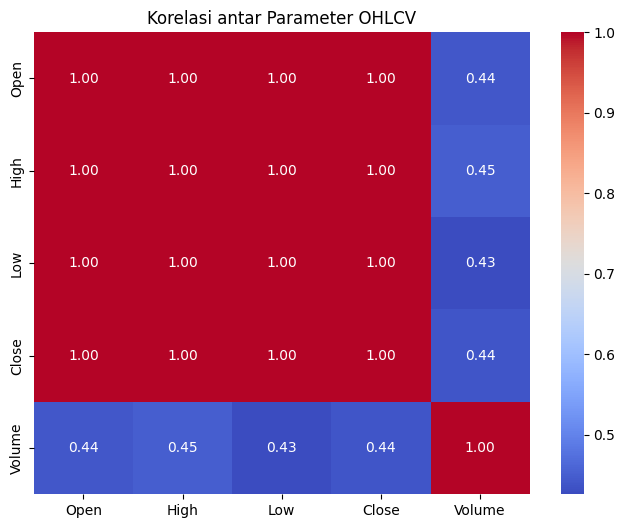

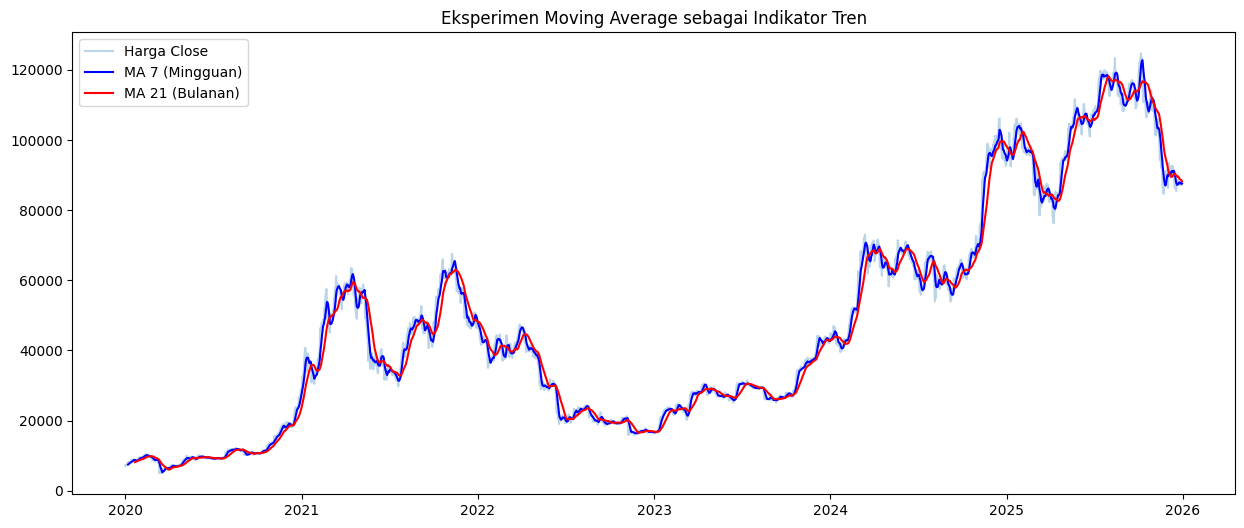

In [16]:
# Pastikan kolom Date bertipe datetime dan menjadi index untuk memudahkan plotting
df['Date'] = pd.to_datetime(df['Date'])
df_eda = df.copy().set_index('Date')

# --- 1. Inspeksi Kualitas Data ---
print("--- Ringkasan Statistik ---")
display(df_eda.describe())

print("\n--- Cek Missing Values ---")
print(df_eda.isnull().sum())

# --- 2. Visualisasi Tren Harga Penutupan ---
plt.figure(figsize=(15, 6))
plt.plot(df_eda['Close'], color='#f2a900', label='Harga Close BTC') # Warna khas Bitcoin
plt.title('Tren Harga Penutupan Bitcoin (2020 - 2025)', fontsize=14)
plt.xlabel('Tahun')
plt.ylabel('Harga (USD)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# --- 3. Analisis Volume Perdagangan ---
plt.figure(figsize=(15, 4))
plt.bar(df_eda.index, df_eda['Volume'], color='gray', alpha=0.3, label='Volume')
plt.title('Volume Perdagangan Harian', fontsize=12)
plt.ylabel('Volume')
plt.legend()
plt.show()

# --- 4. Distribusi Perubahan Harga Harian (Daily Returns) ---
# Ini membantu melihat tingkat risiko/volatilitas
df_eda['Daily_Return'] = df_eda['Close'].pct_change()
plt.figure(figsize=(10, 5))
sns.histplot(df_eda['Daily_Return'].dropna(), bins=100, kde=True, color='purple')
plt.title('Distribusi Perubahan Harga Harian (Volatility)', fontsize=12)
plt.xlabel('Persentase Perubahan')
plt.show()

# --- 5. Matriks Korelasi ---
plt.figure(figsize=(8, 6))
correlation_matrix = df_eda[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi antar Parameter OHLCV', fontsize=12)
plt.show()

# --- 6. Eksperimen Indikator (MA-7 vs MA-21) ---
# Ini untuk menjustifikasi kenapa kita akan melakukan Feature Engineering nanti
plt.figure(figsize=(15, 6))
plt.plot(df_eda['Close'], alpha=0.3, label='Harga Close')
plt.plot(df_eda['Close'].rolling(window=7).mean(), label='MA 7 (Mingguan)', color='blue')
plt.plot(df_eda['Close'].rolling(window=21).mean(), label='MA 21 (Bulanan)', color='red')
plt.title('Eksperimen Moving Average sebagai Indikator Tren', fontsize=12)
plt.legend()
plt.show()

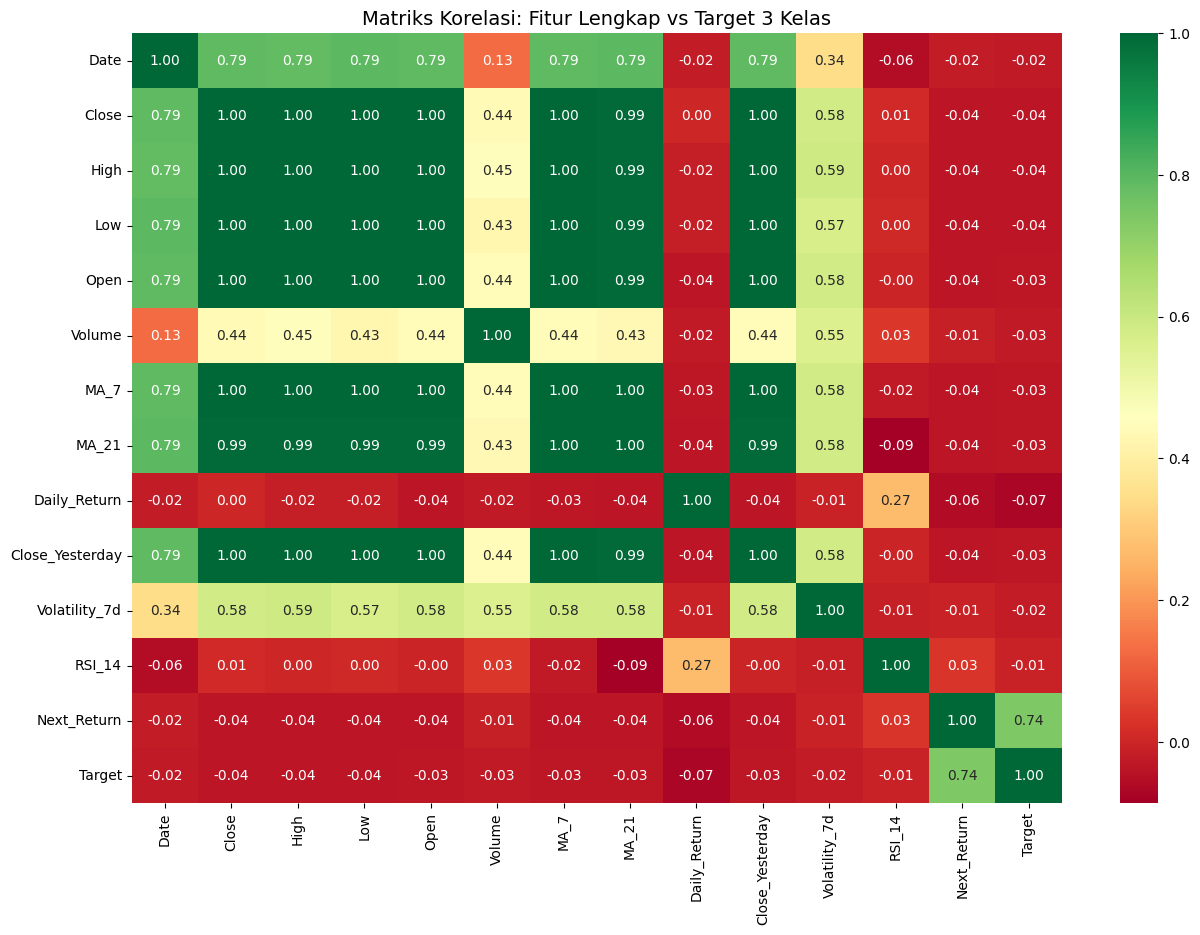


--- Distribusi Target 3 Kelas ---
Target
2.0    0.401843
0.0    0.374194
1.0    0.223963
Name: proportion, dtype: float64

--- Korelasi Fitur terhadap Target ---
Target             1.000000
Next_Return        0.738779
RSI_14            -0.008028
Volatility_7d     -0.019505
Date              -0.024686
Volume            -0.025319
MA_21             -0.032826
MA_7              -0.034418
Open              -0.034531
Close_Yesterday   -0.034537
Low               -0.035595
High              -0.035655
Close             -0.037189
Daily_Return      -0.072685
Name: Target, dtype: float64


In [17]:
df_corr = df.copy()

# --- 1. FEATURE CALCULATION (Termasuk 3 Fitur Baru) ---
df_corr['MA_7'] = df_corr['Close'].rolling(window=7).mean()
df_corr['MA_21'] = df_corr['Close'].rolling(window=21).mean()
df_corr['Daily_Return'] = df_corr['Close'].pct_change()
df_corr['Close_Yesterday'] = df_corr['Close'].shift(1)
df_corr['Volatility_7d'] = df_corr['Close'].rolling(window=7).std()

# RSI_14 Calculation
delta = df_corr['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_corr['RSI_14'] = 100 - (100 / (1 + rs))

# --- 2. TARGET CALCULATION (Logika 3 Kelas) ---
df_corr['Next_Return'] = (df_corr['Close'].shift(-1) - df_corr['Close']) / df_corr['Close']
threshold = 0.005

conditions = [
    (df_corr['Next_Return'] > threshold),
    (df_corr['Next_Return'] < -threshold),
    (df_corr['Next_Return'].between(-threshold, threshold))
]
values = [2, 0, 1]
df_corr['Target'] = np.select(conditions, values, default=np.nan)

# --- 3. VISUALISASI ---
df_corr.dropna(inplace=True)
plt.figure(figsize=(15, 10))
sns.heatmap(df_corr.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Matriks Korelasi: Fitur Lengkap vs Target 3 Kelas', fontsize=14)
plt.show()

print("\n--- Distribusi Target 3 Kelas ---")
print(df_corr['Target'].value_counts(normalize=True))
print("\n--- Korelasi Fitur terhadap Target ---")
print(df_corr.corr()['Target'].sort_values(ascending=False))

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [19]:
df_prep = df.copy()

# --- 1. FEATURE ENGINEERING ---
df_prep['MA_7'] = df_prep['Close'].rolling(window=7).mean()
df_prep['MA_21'] = df_prep['Close'].rolling(window=21).mean()
df_prep['Daily_Return'] = df_prep['Close'].pct_change()
df_prep['Close_Yesterday'] = df_prep['Close'].shift(1)
df_prep['Volatility_7d'] = df_prep['Close'].rolling(window=7).std()

# Perhitungan RSI_14
delta = df_prep['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_prep['RSI_14'] = 100 - (100 / (1 + rs))

# --- 2. MULTI-CLASS TARGET ---
df_prep['Next_Return'] = (df_prep['Close'].shift(-1) - df_prep['Close']) / df_prep['Close']
threshold = 0.005
conditions = [
    (df_prep['Next_Return'] > threshold),
    (df_prep['Next_Return'] < -threshold),
    (df_prep['Next_Return'].between(-threshold, threshold))
]
df_prep['Target'] = np.select(conditions, [2, 0, 1], default=np.nan)

# --- 3. CLEANING ---
df_clean = df_prep.dropna().copy()

X = df_clean.drop(['Target', 'Next_Return'], axis=1)
if 'Date' in X.columns:
    X = X.drop(['Date'], axis=1)

y = df_clean['Target'].astype(int)

# --- 4. PENYIMPANAN DATA UTUH KE CSV (Tanpa Standarisasi) ---
df_final = X.copy()
df_final['Target'] = y.values
df_final.to_csv("btc_preprocessing.csv", index=True)

print(f"Preprocessing Selesai! File 'btc_preprocessing.csv' berhasil disimpan.")
display(df_final.head())

# --- 5. TRAIN-TEST SPLIT---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)

print("\n" + "="*50)
print("DATA BERHASIL DI-SPLIT SECARA KRONOLOGIS (NO SHUFFLE)")
print("="*50)
print(f"Dimensi X_train : {X_train.shape} (Data Masa Lalu)")
print(f"Dimensi X_test  : {X_test.shape} (Data Masa Depan)")
print(f"Dimensi y_train : {y_train.shape}")
print(f"Dimensi y_test  : {y_test.shape}")

Preprocessing Selesai! File 'btc_preprocessing.csv' berhasil disimpan.


,Close,High,Low,Open,Volume,MA_7,MA_21,Daily_Return,Close_Yesterday,Volatility_7d,RSI_14,Target
20,8745.894531,8755.706055,8544.520508,8658.991211,24097418512,8787.489397,8148.824730,0.010194,8657.642578,110.898028,62.743188,0
21,8680.875977,8792.994141,8636.747070,8744.210938,22600204051,8769.470145,8219.334333,-0.007434,8745.894531,117.262327,63.264148,0
22,8406.515625,8687.747070,8333.637695,8680.650391,25770680779,8724.145787,8287.003162,-0.031605,8680.875977,181.554212,61.274399,1
23,8445.434570,8514.666992,8266.840820,8405.567383,24397913026,8655.059570,8339.410319,0.004630,8406.515625,182.601726,56.669992,0
24,8367.847656,8458.453125,8296.218750,8440.119141,19647331549,8572.922294,8384.990839,-0.009187,8445.434570,159.439539,58.099287,2



DATA BERHASIL DI-SPLIT SECARA KRONOLOGIS (NO SHUFFLE)
Dimensi X_train : (1519, 11) (Data Masa Lalu)
Dimensi X_test  : (651, 11) (Data Masa Depan)
Dimensi y_train : (1519,)
Dimensi y_test  : (651,)
